<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/Placement_dataset_training_and_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv("/placement.csv")

In [ ]:
print(df.head())

   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0


**Removed** Unnecessary Column

In [ ]:
df = df.drop("Unnamed: 0", axis=1)

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None


In [ ]:
print(df.describe())

             cgpa          iq   placement
count  100.000000  100.000000  100.000000
mean     5.991000  123.580000    0.500000
std      1.143634   39.944198    0.502519
min      3.300000   37.000000    0.000000
25%      5.075000  101.500000    0.000000
50%      6.000000  127.500000    0.500000
75%      6.900000  149.000000    1.000000
max      8.500000  233.000000    1.000000


In [ ]:
print(df.isnull().sum())

cgpa         0
iq           0
placement    0
dtype: int64


In [ ]:
X = df[['cgpa', 'iq']]

In [ ]:
y = df['placement']

Now **Split** the Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Normalize** the Data

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(8, activation='relu', input_shape=(2,)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3438 - loss: 0.7360 - val_accuracy: 0.6250 - val_loss: 0.6699
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3594 - loss: 0.7262 - val_accuracy: 0.6250 - val_loss: 0.6660
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3594 - loss: 0.7171 - val_accuracy: 0.6250 - val_loss: 0.6625
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4219 - loss: 0.7104 - val_accuracy: 0.7500 - val_loss: 0.6598
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4844 - loss: 0.7036 - val_accuracy: 0.7500 - val_loss: 0.6574
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5469 - loss: 0.6977 - val_accuracy: 0.8125 - val_loss: 0.6550
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5625 - loss: 0.6922 - val_accuracy: 0.8125 - val_loss: 0.6519
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5781 - loss: 0.6866 - val_accuracy: 0.7500 - val_loss:

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8500 - loss: 0.3117
Accuracy: 0.8500000238418579


Predit Now

In [ ]:
student =np.array([[7.5, 120]])
student = scaler.transform(student)
prediction = model.predict(student)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[0.9980873]]


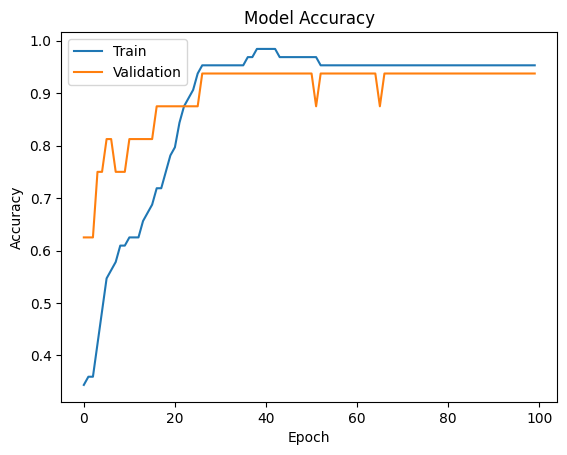

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

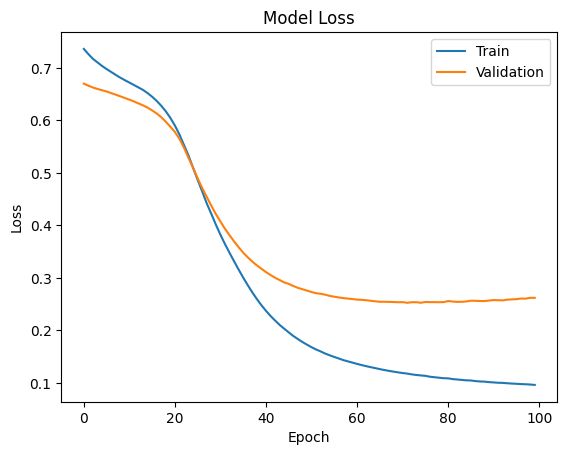

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()